# Skills Clustering / Balancing 🤹‍♀️🌌

### Objective

1. Develop a method to rebalance teams based on skill matrix scores.  Minimize the difference between team skills scores, with teams of variable sizes.
    * Greedy
    * Clustering
    * Linear Programming Minimization
2. Cluster similar individuals based on skills ratings
    * K-Means Clustering
    * Segmentation analysis
3. Recommendation of similar students

|Team Rebalancing Assumption| Note|
|----------|-----|
|Team sizes can vary||
|Number of teams can change||
|At least 1 person from each skill > 50 on each team|Adjustable|

Items to discuss:
* do we keep the area specific skill ratings in the data?

Todo:
* visualize team skill type distribution before and after
* create a table with student and 2 recommendations for every student
* ACTUAL Data - incorportate 

## Import data

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

In [3]:
# Import data from excel
data = pd.read_excel('scores.xlsx')
data.head(5)

,Student,Reading,Writing,Math,Science,Team
0,1,50,53,55,41,3
1,2,12,15,19,20,1
2,3,5,11,14,15,3
3,4,66,23,16,100,3
4,5,52,100,49,9,0


In [4]:
# Create dataframe for PCA analysis
data_pca = data.drop(['Student', 'Team'], axis=1)

In [5]:
# Calculate the average score for each student
data['Average'] = data.mean(axis=1)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  func(x=vector, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  func(x=vector, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  func(x=vector, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: Numpy array is not a supported type for `palette`. Pl

<Figure size 400x400 with 0 Axes>

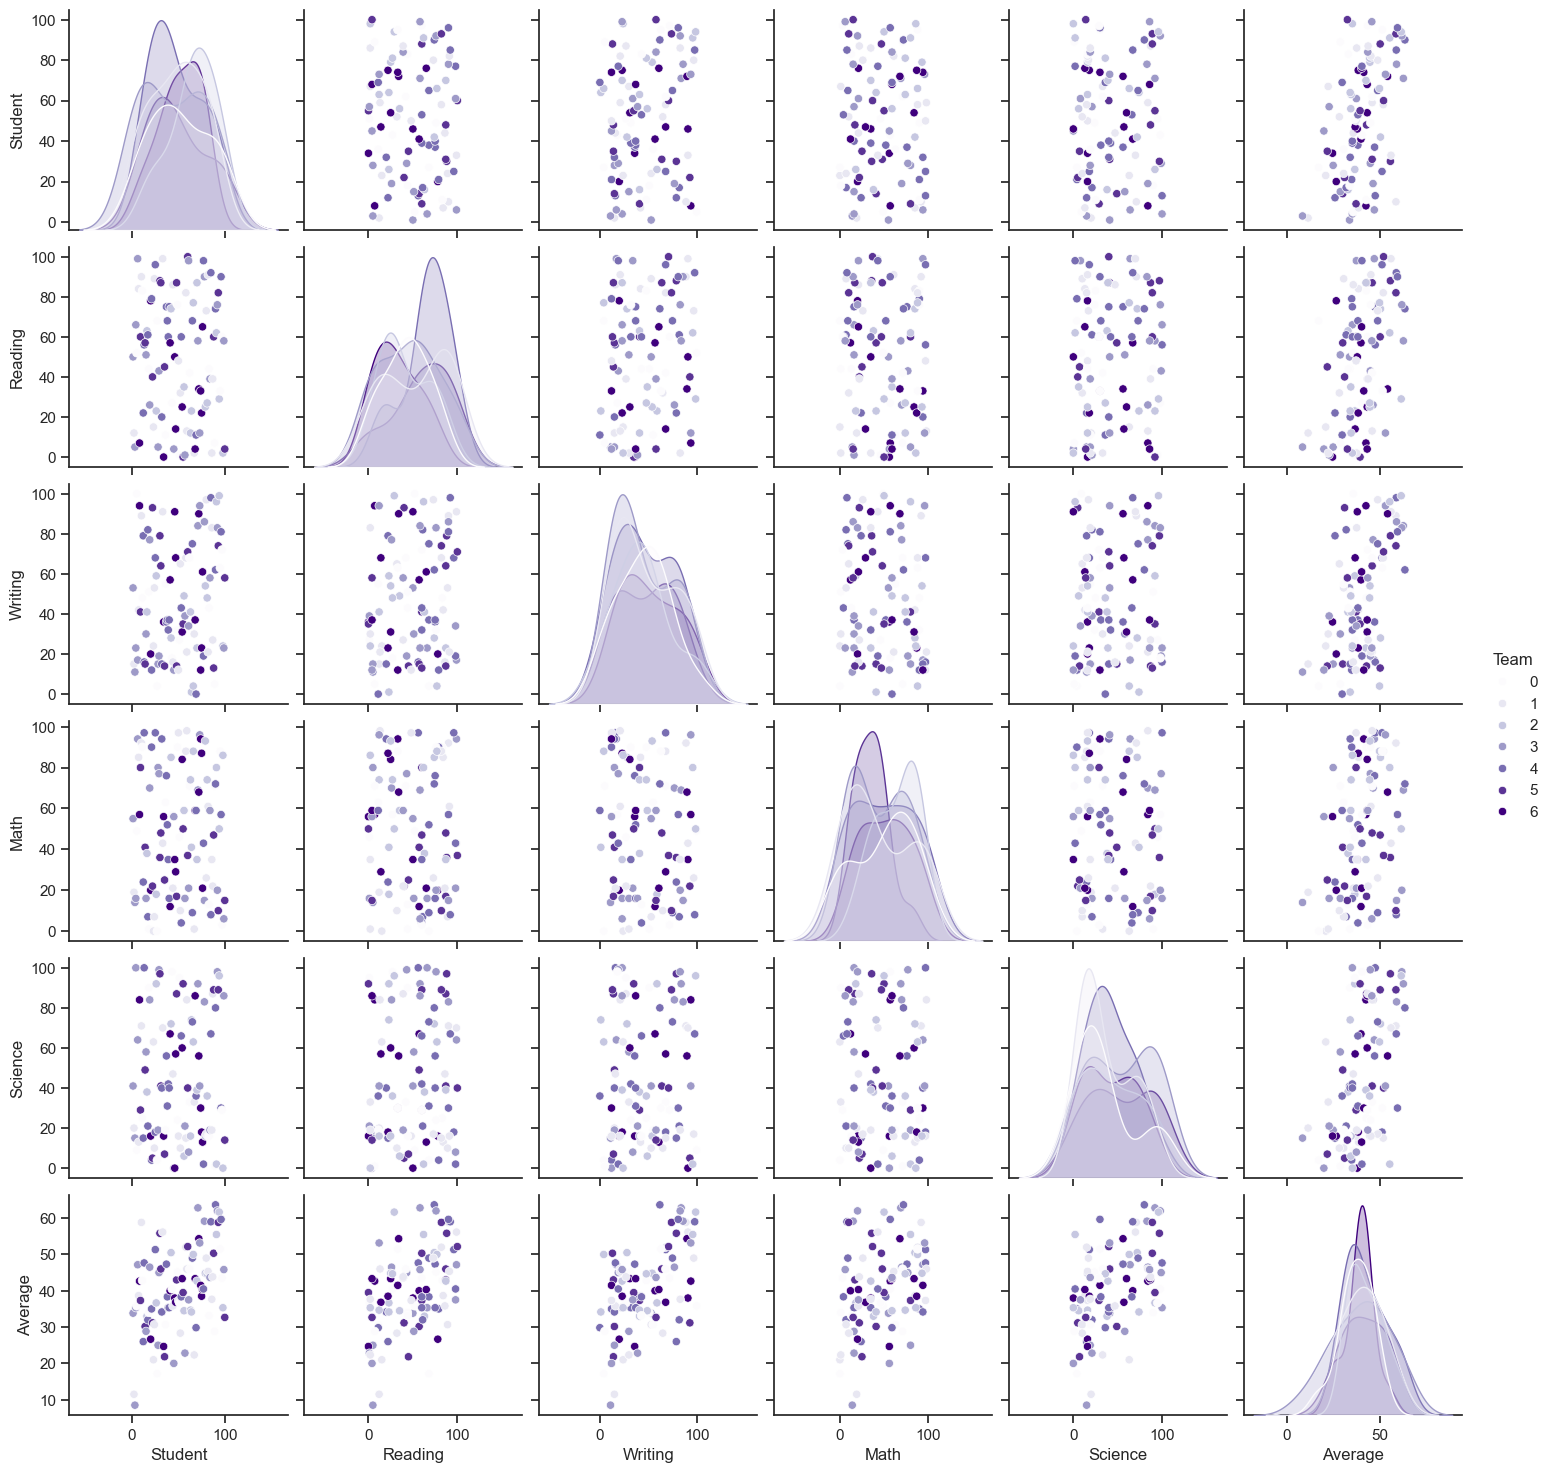

In [6]:
# Pair plot of features
plt.figure(figsize=(4,4))
sns.set_theme(style="ticks", color_codes=True);# Create a custom color palette

purple_cmap = sns.color_palette("Purples", as_cmap=True)
colors = purple_cmap(np.linspace(0, 1, num=len(data['Team'].unique())))
sns.pairplot(data, hue='Team', palette=colors) #, palette=palette
plt.show()

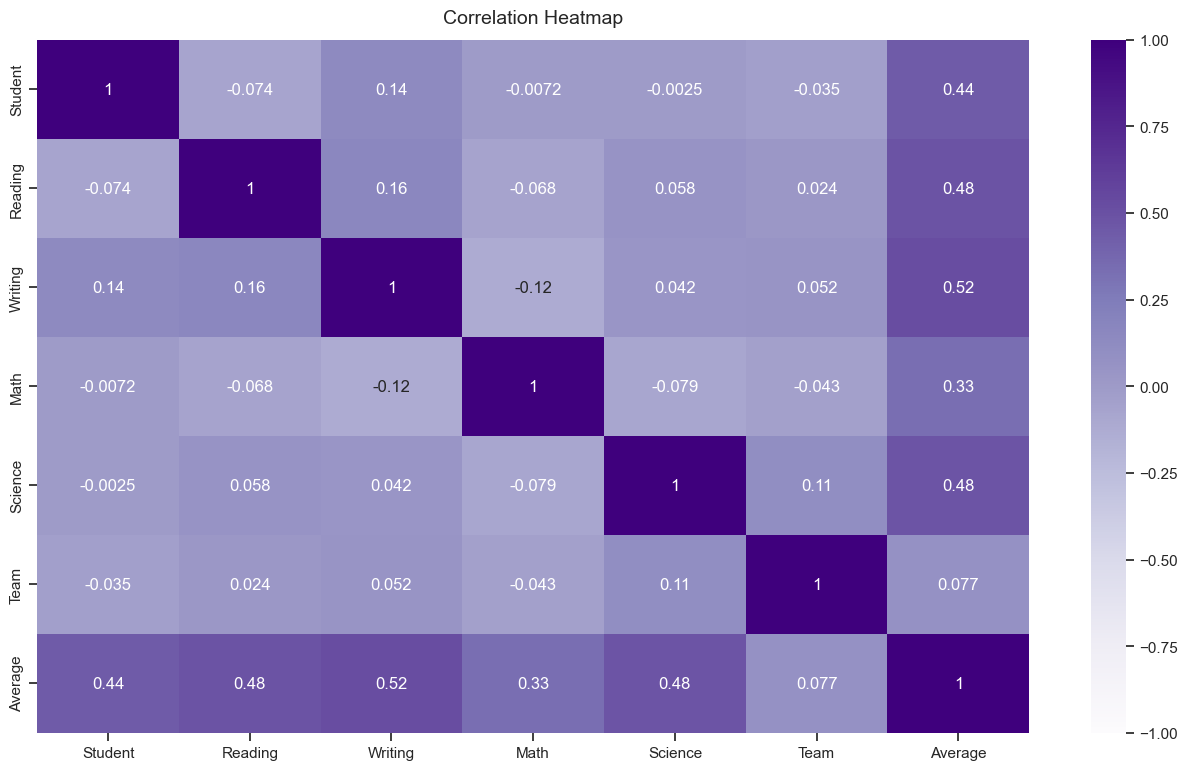

In [7]:
# Plot a correlation heatmap
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(data.corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("Purples", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);
plt.show()

In [8]:
# Create column for 'Average' score
data['Average'] = data[['Reading', 'Writing', 'Math', 'Science']].mean(axis=1)

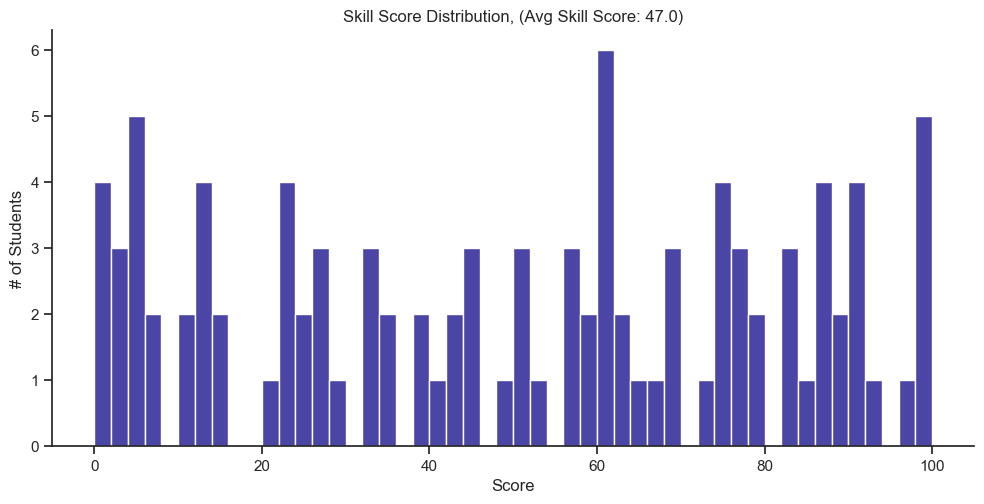

In [9]:
# Histogram plot of Average Scores
sns.displot(data['Reading'], 
            bins=50, 
            aspect=2,
            # kde=True, 
            color='#0e0887')

plt.title(f'Skill Score Distribution, (Avg Skill Score: {(data.Average.mean()):,.1f})')
plt.xlabel('Score')
plt.ylabel('# of Students')

plt.show()

<hr>

## Greedy Algorithm

In [10]:
# Greedy Algorithm with specified team sizes
team_sizes = [25, 15, 20, 20, 20]
team_indices = {i+1: [] for i in range(5)}
data_sorted = data.sort_values(by='Average', ascending=False)

start_idx = 0
for i, size in enumerate(team_sizes):
    team_indices[i+1] = data_sorted.index[start_idx:start_idx+size].tolist()
    start_idx += size

teams_greedy_df = {k: data.loc[v] for k, v in team_indices.items()}


<hr>

## K-Means Clustering

In [11]:
# Method 2: K-means Clustering adjusted for team sizes
kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(data[['Reading', 'Writing', 'Math', 'Science']])

# Get indices of each cluster
clusters = {i: data[data['Cluster'] == i].index.tolist() for i in range(5)}

# Sort clusters by average score
clusters_sorted = sorted(clusters.items(), key=lambda x: -data.loc[x[1], 'Average'].mean())

# Adjust clusters to match the specified team sizes
team_indices_kmeans = {i+1: [] for i in range(5)}
start_idx = 0
for i, size in enumerate(team_sizes):
    cluster_idx, cluster = clusters_sorted[i]
    team_indices_kmeans[i+1] = cluster[:size]
    clusters_sorted[i] = (cluster_idx, cluster[size:])

# Redistribute leftover students
leftover_students = [student for _, cluster in clusters_sorted for student in cluster]
for team, size in zip(team_indices_kmeans.keys(), team_sizes):
    current_size = len(team_indices_kmeans[team])
    if current_size < size:
        needed = size - current_size
        team_indices_kmeans[team].extend(leftover_students[:needed])
        leftover_students = leftover_students[needed:]

teams_kmeans_df = {k: data.loc[v] for k, v in team_indices_kmeans.items()}

In [12]:
# Convert teams_ilp_df into a single DataFrame with a column for the team
teams_kmeans = pd.concat([df.assign(Team=k) for k, df in teams_kmeans_df.items()])
teams_kmeans.head()

,Student,Reading,Writing,Math,Science,Team,Average,Cluster
3,4,66,23,16,100,1,51.25,3
7,8,7,94,57,84,1,60.50,3
9,10,90,89,92,71,1,85.50,3
17,18,44,51,1,90,1,46.50,3
18,19,26,77,70,84,1,64.25,3


### PCA Dimensionality Reduction 

In [13]:
#Initiating PCA to reduce dimentions aka features to 3
pca = PCA(n_components=3)
pca.fit(data_pca)
PCA_ds = pd.DataFrame(pca.transform(data_pca), columns=(["col1","col2", "col3"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,100.0,-5.471179e-15,34.511310,-76.873964,-24.135469,0.696510,21.365329,77.235088
col2,100.0,6.572520e-16,31.147925,-53.244794,-22.225661,-1.519794,18.820021,70.693875
col3,100.0,-2.842171e-16,29.855648,-66.362141,-20.000321,-2.885878,20.092335,68.358478


In [14]:
PCA_ds['Cluster'] = teams_kmeans['Cluster']

In [15]:
import plotly.graph_objects as go

# A 3D Projection Of Data In The Reduced Dimension
x = PCA_ds["col1"]
y = PCA_ds["col2"]
z = PCA_ds["col3"]
cluster = PCA_ds['Cluster']
index = PCA_ds.index

# To plot
fig = go.Figure(data=[go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers',
    marker=dict(
        size=6,
        color=cluster,                # set color to an array/list of desired values
        colorscale='Viridis',           # choose a colorscale
        opacity=0.8
    ),
    text=['Person: ' + str(i) for i in index],
    hoverinfo='text'
)])

fig.update_layout(title="ScatterPlot of Reduced Dimension Skills (K-Means)",
                  width=800,
                  height=700,
                  autosize=False,
                  scene=dict(xaxis=dict(title='col1'),
                             yaxis=dict(title='col2'),
                             zaxis=dict(title='col3'),
                             aspectratio=dict(x=1, y=1, z=0.7),
                             aspectmode='manual')
                 )

fig.show()


In [16]:
PCA_ds.head()

,col1,col2,col3,Cluster
0,1.943384,-4.318835,5.020127,0
1,30.740720,6.026259,-49.478626,1
2,36.248331,6.204242,-58.464877,1
3,-45.642715,41.973330,-4.034262,3
4,-4.441570,-46.597529,-6.347395,2


In [17]:
PCA_ds['Student'] = data['Student']
PCA_ds = pd.merge(PCA_ds, data, on='Student')
PCA_ds = PCA_ds.rename(columns={'Cluster_x': 'Cluster'})

In [18]:
import plotly.express as px

fig = px.scatter_3d(PCA_ds, x='col1', y='col2', z='col3',
                    color='Cluster',
                    opacity=0.7,
                    title="Student Clusters Based on Skills",
                    hover_data=['Student', 'Reading', 'Writing', 'Math', 'Science'],
                    height=600)
fig.show()

In [19]:
# Export the plot as an HTML file
import plotly.graph_objects as go
import plotly.io as pio

# Write the scatterplot to an HTML file
pio.write_html(fig, file='scatterplot.html')

In [20]:
import plotly.express as px
fig = px.box(data, x='Team', y='Average', points='all')
fig.update_traces(marker=dict(color='#0e0887'))
fig.show()

In [21]:
# Write the scatterplot to an HTML file
pio.write_html(fig, file='boxplot_current.html')

In [22]:
teams_ilp_flat = data.melt(id_vars=['Student', 'Team','Cluster','Average'], var_name='Subject', value_name='Score')
teams_ilp_flat

,Student,Team,Cluster,Average,Subject,Score
0,1,3,0,49.75,Reading,50
1,2,1,1,16.50,Reading,12
2,3,3,1,11.25,Reading,5
3,4,3,3,51.25,Reading,66
4,5,0,2,52.50,Reading,52
...,...,...,...,...,...,...
395,96,4,0,64.50,Science,30
396,97,0,2,41.00,Science,29
397,98,2,4,28.00,Science,0
398,99,3,3,43.25,Science,86


In [23]:
fig = px.scatter(teams_ilp_flat, x='Team', y='Score', facet_col='Subject', color='Cluster', hover_data=['Student'])
fig.add_hline(y=70, line_width=2, line_dash="dash", line_color="grey")
fig.update_layout(title='Subject Skills by Team')
fig.update_traces(opacity=0.6)
fig.show()

In [24]:
# Write the scatterplot to an HTML file
pio.write_html(fig, file='teamskills_current.html')

<hr>

## Linear Programming Model

In [25]:
# Integer Linear Programming (ILP) with specified team sizes
# Objective: Minimize the difference between the maximum and minimum team averages

# Number of students
num_students = len(data)
# Number of teams to be formed
num_teams = 5
# Desired sizes for each team
team_sizes = [15, 25, 20, 20, 20]
# Initialize the solver
solver = pywraplp.Solver.CreateSolver('SCIP')

# Set the time limit for the solver (in milliseconds)
solver.SetTimeLimit(600000)

# Create binary decision variables x[i,j] indicating whether student i is assigned to team j
x = {}
for i in range(num_students):
    for j in range(num_teams):
        x[i, j] = solver.BoolVar(f'x[{i},{j}]')

# Constraint 1: Each student can be assigned to only one team
for i in range(num_students):
    solver.Add(sum(x[i, j] for j in range(num_teams)) == 1)

# Constraint 2: Each team must have the specified size
for j in range(num_teams):
    solver.Add(sum(x[i, j] for i in range(num_students)) == team_sizes[j])

# Constraint 3: Add constraints for at least 1 student with a score of 70 or more in each of the columns 'Reading', 'Writing', 'Math', and 'Science'
for j in range(num_teams):
    solver.Add(
        solver.Sum([x[i, j]
                    for i in range(num_students)
                    if data['Reading'].iloc[i] >= 50]) >= 1
    )
    solver.Add(
        solver.Sum([x[i, j]
                    for i in range(num_students)
                    if data['Writing'].iloc[i] >= 50]) >= 1
    )
    solver.Add(
        solver.Sum([x[i, j]
                    for i in range(num_students)
                    if data['Math'].iloc[i] >= 50]) >= 1
    )
    solver.Add(
        solver.Sum([x[i, j]
                    for i in range(num_students)
                    if data['Science'].iloc[i] >= 50]) >= 1
    )

# Calculate the average score for each team
team_averages = []
for j in range(num_teams):
    team_averages.append(solver.Sum([x[i, j] * data['Average'].iloc[i] for i in range(num_students)]))

# Create variables for the maximum and minimum team averages
max_team_avg = solver.NumVar(0, solver.infinity(), 'max_team_avg')
min_team_avg = solver.NumVar(0, solver.infinity(), 'min_team_avg')

# Constraints for the maximum and minimum team averages
for j in range(num_teams):
    solver.Add(max_team_avg >= team_averages[j] / team_sizes[j])
    solver.Add(min_team_avg <= team_averages[j] / team_sizes[j])

# Objective function: Minimize the difference between the maximum and minimum team averages
solver.Minimize(max_team_avg - min_team_avg)

# Solve the model
status = solver.Solve()

# If the model is solved optimally or feasibly, print the team assignments
# Otherwise, print that the problem does not have an optimal solution
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    teams_ilp = {i: [] for i in range(num_teams)}
    for i in range(num_students):
        for j in range(num_teams):
            if x[i, j].solution_value() == 1:
                teams_ilp[j].append(i)
    teams_ilp_df = {k: data.iloc[v] for k, v in teams_ilp.items()}
else:
    print('The ILP problem does not have an optimal solution.')


<hr>

## Results

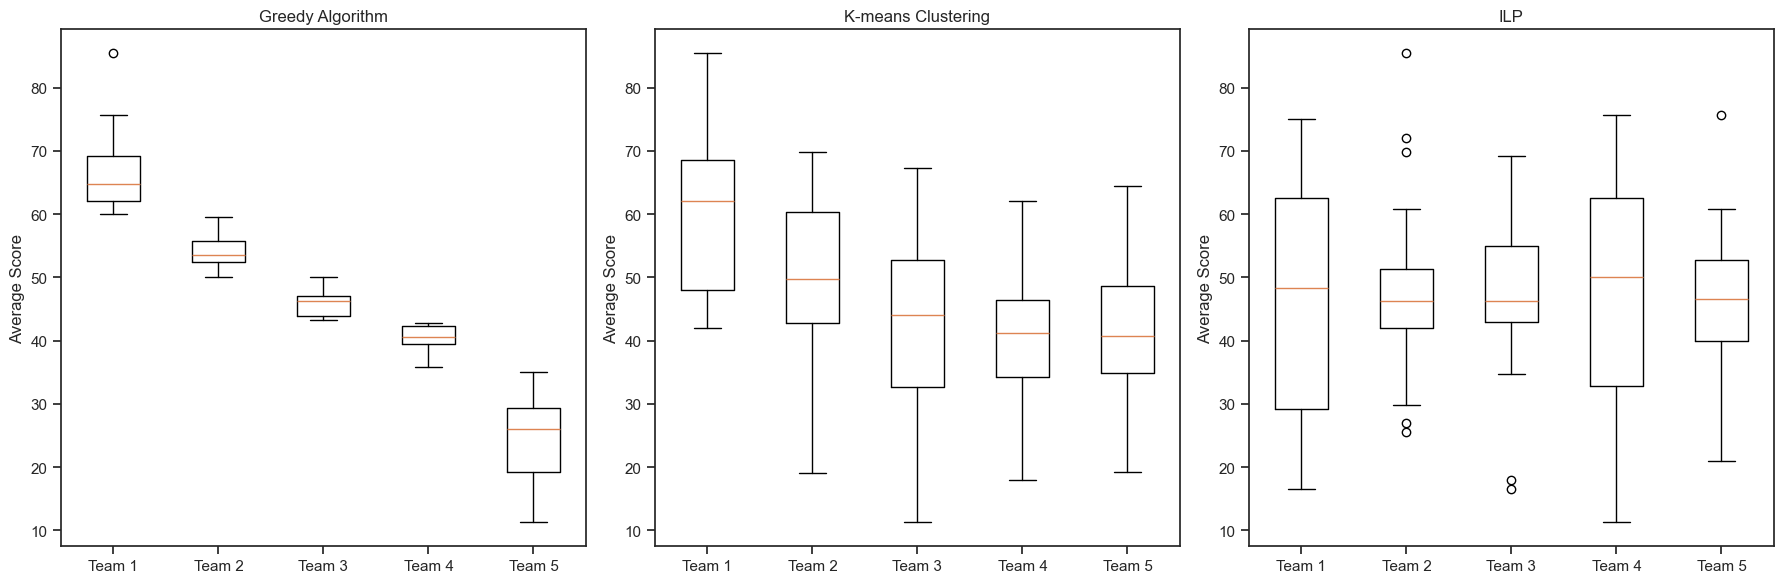

In [26]:
# Plotting the box plots for each method
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Greedy Algorithm
greedy_averages = [team['Average'] for team in teams_greedy_df.values()]
axs[0].boxplot(greedy_averages)
axs[0].set_title('Greedy Algorithm')
axs[0].set_xticklabels(['Team 1', 'Team 2', 'Team 3', 'Team 4', 'Team 5'])
axs[0].set_ylabel('Average Score')

# K-means Clustering
kmeans_averages = [team['Average'] for team in teams_kmeans_df.values()]
axs[1].boxplot(kmeans_averages)
axs[1].set_title('K-means Clustering')
axs[1].set_xticklabels(['Team 1', 'Team 2', 'Team 3', 'Team 4', 'Team 5'])
axs[1].set_ylabel('Average Score')

# ILP
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    ilp_averages = [team['Average'] for team in teams_ilp_df.values()]
    axs[2].boxplot(ilp_averages)
    axs[2].set_title('ILP')
    axs[2].set_xticklabels(['Team 1', 'Team 2', 'Team 3', 'Team 4', 'Team 5'])
    axs[2].set_ylabel('Average Score')
else:
    axs[2].text(0.5, 0.5, 'No Optimal Solution', horizontalalignment='center', verticalalignment='center')
    axs[2].set_title('ILP')

plt.tight_layout()
plt.show()


In [27]:
# Convert teams_ilp_df into a single DataFrame with a column for the team
teams_ilp_combined = pd.concat([df.assign(Team=k) for k, df in teams_ilp_df.items()])

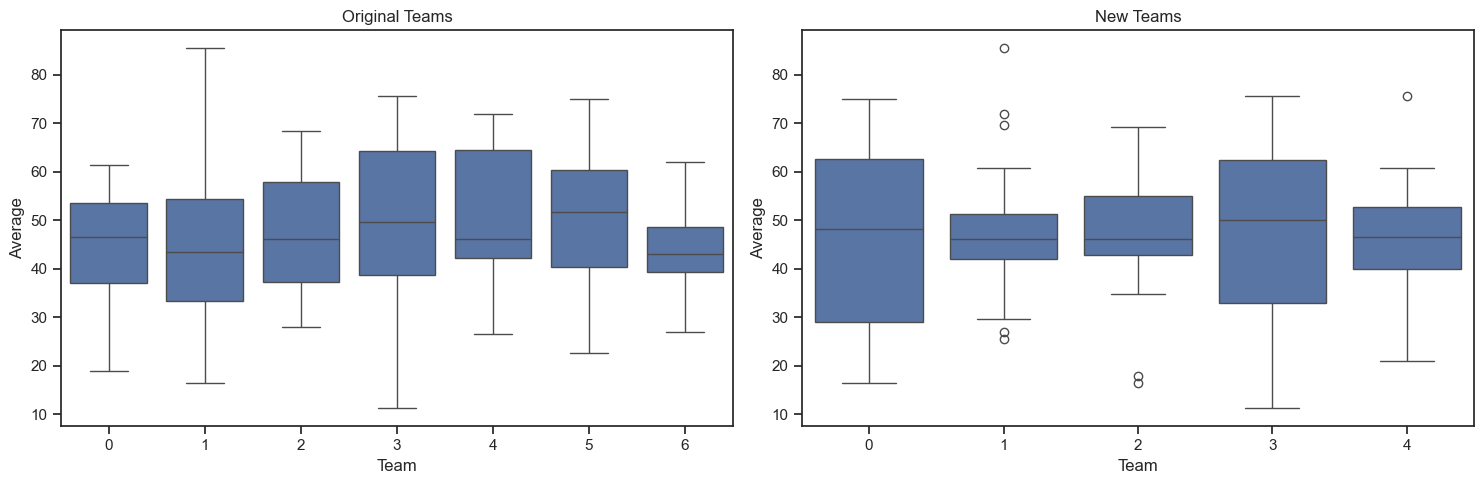

In [28]:
# Create a figure with 3 subplots
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot the first boxplot
sns.boxplot(data=data, x='Team', y='Average', ax=axs[0])
axs[0].set_title('Original Teams')

# Plot the second boxplot
sns.boxplot(data=teams_ilp_combined, x='Team', y='Average', ax=axs[1])
axs[1].set_title('New Teams')

# Adjust the spacing between subplots
fig.tight_layout()

# Display the plot
plt.show()

In [29]:
# Display original team averages
original_teams = data.groupby('Team')['Average'].mean()
print(original_teams)

Team
0    43.250000
1    45.421875
2    47.634615
3    47.750000
4    50.852941
5    48.916667
6    44.458333
Name: Average, dtype: float64


In [31]:
# Exporting the Series to an HTML file
original_teams.to_frame().to_html('team_series.html', index=False)

In [ ]:
# Print the average of all teams for each method
print("Greedy Algorithm Team Averages:")
for i, team in teams_greedy_df.items():
    print(f"Team {i}: {team['Average'].mean():.2f}")

print("\nK-means Clustering Team Averages:")
for i, team in teams_kmeans_df.items():
    print(f"Team {i}: {team['Average'].mean():.2f}")

if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    print("\nILP Team Averages:")
    for i, team in teams_ilp_df.items():
        print(f"Team {i}: {team['Average'].mean():.2f}")
else:
    print("\nILP did not find an optimal solution.")

Greedy Algorithm Team Averages:
Team 1: 66.80
Team 2: 53.95
Team 3: 45.96
Team 4: 40.33
Team 5: 25.00

K-means Clustering Team Averages:
Team 1: 59.46
Team 2: 48.85
Team 3: 42.01
Team 4: 40.30
Team 5: 41.98

ILP Team Averages:
Team 0: 47.05
Team 1: 47.05
Team 2: 47.05
Team 3: 47.05
Team 4: 47.05


In [ ]:
# Display new team average based on the Linear Programming solution
group = teams_ilp_combined.groupby('Team')['Average'].mean()
group

Team
0    47.05
1    47.05
2    47.05
3    47.05
4    47.05
Name: Average, dtype: float64

In [ ]:
# Display count of new teams from the Linear Programming solution
group = teams_ilp_combined.groupby('Team')['Average'].count()
group

Team
0    15
1    25
2    20
3    20
4    20
Name: Average, dtype: int64

In [ ]:
# Export results to excel
teams_ilp_combined.to_excel('results.xlsx')

In [ ]:
teams_ilp_combined.head()

,Student,Reading,Writing,Math,Science,Team,Average,Cluster
6,7,84,42,85,13,0,56.00,0
13,14,57,15,41,49,0,40.50,0
29,30,88,79,36,97,0,75.00,3
30,31,87,64,48,41,0,60.00,0
34,35,45,14,25,7,0,22.75,0


In [ ]:
import plotly.express as px

fig = px.scatter(teams_ilp_combined, x='Team', y='Reading')
fig.show()

In [ ]:
teams_ilp_flat = teams_ilp_combined.melt(id_vars=['Student','Team','Cluster', 'Average'], var_name='Subject', value_name='Score')
teams_ilp_flat

,Student,Team,Cluster,Average,Subject,Score
0,7,0,0,56.00,Reading,84
1,14,0,0,40.50,Reading,57
2,30,0,3,75.00,Reading,88
3,31,0,0,60.00,Reading,87
4,35,0,0,22.75,Reading,45
...,...,...,...,...,...,...
395,88,4,1,52.25,Science,89
396,89,4,4,21.00,Science,1
397,95,4,4,53.50,Science,30
398,97,4,2,41.00,Science,29


In [ ]:
fig = px.scatter(teams_ilp_flat, x='Team', y='Score', facet_col='Subject', color='Cluster', hover_data=['Student'])
fig.add_hline(y=70, line_width=2, line_dash="dash", line_color="grey")
fig.update_layout(title='Subject Skills by Team')
fig.update_traces(opacity=0.6)
fig.show()

In [ ]:
# Write the scatterplot to an HTML file
pio.write_html(fig, file='teamskills.html')

In [ ]:
import plotly.express as px
fig = px.box(teams_ilp_flat, x='Team', y='Average', points='all')
fig.update_traces(marker=dict(color='#0e0887'))
fig.show()

In [ ]:
# Write the scatterplot to an HTML file
pio.write_html(fig, file='teamskills_future.html')

<hr>

## Recommend neighbor 

In [ ]:
df = teams_ilp_combined.copy()

In [ ]:
import numpy as np
from scipy.spatial.distance import euclidean

identified_student = 99 # replace with the ID of the identified student
identified_student_scores = df[df['Student'] == identified_student][['Reading', 'Writing', 'Math', 'Science']].values[0]

def find_similar_students(student_scores, df):
    distances = []
    for i in range(len(df)):
        scores = df.iloc[i][['Reading', 'Writing', 'Math', 'Science']].values
        distance = euclidean(student_scores, scores)
        distances.append((i, distance))
    distances.sort(key=lambda x: x[1])
    similar_student_indices = [d[0] for d in distances[:3]]
    similar_students = df.iloc[similar_student_indices][['Student']]
    similar_students['distance'] = [d[1] for d in distances[:3]]
    return similar_students

similar_students = find_similar_students(identified_student_scores, df)
similar_students


,Student,distance
98,99,0.000000
3,4,18.973666
86,87,25.179357


In [ ]:
merged_df = df.merge(similar_students, on='Student').sort_values(by='distance')
print('Recommended similar students:')
merged_df

Recommended similar students:


,Student,Reading,Writing,Math,Science,Team,Average,Cluster,distance
2,99,58,23,6,86,4,43.25,3,0.000000
1,4,66,23,16,100,4,51.25,3,18.973666
0,87,39,27,22,87,3,43.75,1,25.179357
